In [1]:
import os
import pickle

# Third parties
import numpy as np
import pandas as pd
# Import from other modules
from model.common import fromYaml
from data.EOSdataset import DataSet
from model.common import fromFolder



/opt/conda/envs/pennylane/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-16 09:21:00.294827: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 09:21:00.381831: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-16 09:21:02.102062: I tensorflow/core/util/por

# Using transformer embedding training on everything with the AD dataset

In [2]:
input_path = '/eos/user/c/cebrown/RobustQML/AD_dataset/processed/'
embedding_model_path = 'AD_Contrastive_Embedding/Transformer/all/TransformerEmbedding'
output_path = 'AD/transformer/all'
os.makedirs(output_path, exist_ok=True)

In [3]:
embedding_model = fromFolder(embedding_model_path)

I0000 00:00:1776324639.456986 1316095 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78763 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:ad:00.0, compute capability: 9.0
/opt/conda/envs/pennylane/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/opt/conda/envs/pennylane/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Run the embedding prediction

In [4]:
train_labels = {"background" : 0, "ato4l" :1, "hChToTauNu" : 2, 'hToTauTau':3,'leptoquark':4}


In [ ]:

training_columns = []
dataset_list = []
for datasets in train_labels.keys():
    data_test = DataSet.fromH5(input_path+datasets+'/train/')
    data_test.normalise()

    data_test.set_label(train_labels[datasets])
    dataset_list.append(data_test)
    training_columns = data_test.training_columns
        
train_data_frame = pd.concat([dataset.data_frame for dataset in dataset_list])
train_data_frame = train_data_frame.sample(frac=1)

train_embeddings = embedding_model.encoder_predict(train_data_frame[training_columns].to_numpy(),training_columns) 



# Save the embeddings for later use

In [ ]:
os.makedirs(output_path+'/embeddings/train', exist_ok=True)
np.save(output_path+'/embeddings/train/train_embeddings.npy',train_embeddings)
train_data_frame.to_pickle(output_path+'/embeddings/train/dataset.pkl')

# Load them or skip here when the embedding model has already run

In [5]:
train_embeddings = np.load(output_path+'/embeddings/train/train_embeddings.npy')
train_data_frame = pd.read_pickle(output_path+'/embeddings/train/dataset.pkl')

# Train an MLP autoencoder on the embedding

# Only use background for AE training

In [6]:
background_indices = np.where(train_data_frame["event_label"] == 0)
background_embeddings = train_embeddings[background_indices]
background_data_frame = train_data_frame.iloc[background_indices]

# Find the min and max of the training set

In [7]:
embedding_max, embedding_min = np.percentile(train_embeddings,100), np.percentile(train_embeddings,0)
print(np.min(train_embeddings),np.max(train_embeddings))
print(embedding_max,embedding_min)

-3.4047947 4.822231
4.822231 -3.4047947


## Train the CAE model

In [9]:
CAE_model = fromYaml('model/configs/EmbeddingClassicalAEModel.yaml',output_path+'/models/CAE')
input_shape = background_embeddings.shape[0]
input_length = len(background_data_frame)
CAE_model.build_model(input_shape,embedding_min, embedding_max )
CAE_model.compile_model(input_length)
CAE_model.only_CAE_fit(background_embeddings)
CAE_model.save()
CAE_model.plot_loss()

Re-created existing directory: AD/transformer/all/models/CAE.
Epoch 1/20


2026-04-15 21:23:53.837429: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fcd64005110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-15 21:23:53.837489: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA H100 80GB HBM3, Compute Capability 9.0
2026-04-15 21:23:53.904738: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-15 21:23:54.289845: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
I0000 00:00:1776281038.069693 1052650 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-04-15 21:24:53.535018: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_333', 12 

7094/7094 - 72s - 10ms/step - loss: 0.7406 - mae: 0.7406 - mean_squared_error: 1.2153 - val_loss: 0.7238 - val_mae: 0.7238 - val_mean_squared_error: 1.1966 - learning_rate: 0.0010
Epoch 2/20
7094/7094 - 60s - 8ms/step - loss: 0.7227 - mae: 0.7227 - mean_squared_error: 1.1965 - val_loss: 0.7224 - val_mae: 0.7224 - val_mean_squared_error: 1.1965 - learning_rate: 0.0010
Epoch 3/20
7094/7094 - 61s - 9ms/step - loss: 0.7223 - mae: 0.7223 - mean_squared_error: 1.1965 - val_loss: 0.7222 - val_mae: 0.7222 - val_mean_squared_error: 1.1965 - learning_rate: 0.0010
Epoch 4/20
7094/7094 - 57s - 8ms/step - loss: 0.7222 - mae: 0.7222 - mean_squared_error: 1.1965 - val_loss: 0.7222 - val_mae: 0.7222 - val_mean_squared_error: 1.1965 - learning_rate: 0.0010
Epoch 5/20
7094/7094 - 55s - 8ms/step - loss: 0.7222 - mae: 0.7222 - mean_squared_error: 1.1965 - val_loss: 0.7221 - val_mae: 0.7221 - val_mean_squared_error: 1.1965 - learning_rate: 0.0010
Epoch 6/20
7094/7094 - 60s - 9ms/step - loss: 0.7222 - mae: 

TypeError: write() argument must be str, not numpy.float32

In [8]:
CAE_model = fromFolder(output_path+'/models/CAE')

# Train a BDT on the embedding

## Train the model

In [10]:
IF_model = fromYaml('model/configs/IsolationTreeModel.yaml',output_path+'/models/IF')
os.makedirs(output_path+'/models/IF/plots', exist_ok=True)
input_shape = background_embeddings.shape[0]
input_length = len(background_data_frame)
IF_model.build_model(input_shape)
IF_model.compile_model(input_length)
IF_model.fit_on_embedding(background_embeddings)
IF_model.save()
IF_model.plot_loss()

Re-created existing directory: AD/transformer/all/models/IF.
Train model on 8071149 examples


[Warning] On large datasets, using discretized numerical features (i.e. `discretize_numerical_columns=True`) can significantly speed-up training without impact on model quality.


Model trained in 0:00:00.014254
Model saved to AD/transformer/all/models/IF/model/saved_model/
Not implemented for tree based methods


In [9]:
IF_model = fromFolder(output_path+'/models/IF')

Loading model from AD/transformer/all/models/IF/model/saved_model/


# Train a QAE on the embedding

## Train the model

Re-created existing directory: AD/transformer/all/models/QAE.
circuit_weights: [ 5.71954606e-03  6.02706377e-03  1.36336620e-02  6.88628353e-03
  6.38884610e-03  1.20309314e-02  3.14690759e-04  2.99151106e-04
  1.37565848e-02  1.08509135e-02  1.45994809e-02 -1.22753578e-02
 -8.63284250e-05 -5.07732715e-03  5.08843005e-03 -1.97482469e-03
  5.88583363e-04  1.78054638e-02 -1.85517274e-02  6.89108688e-03
 -2.97409719e-04  8.35879373e-03 -1.11943063e-02  3.37208081e-03
  2.41606655e-03  3.88988046e-03  2.45349910e-03 -1.50012957e-02
 -1.13665908e-02  1.22219945e-02  1.12151340e-02  8.35306573e-03]
Device: lightning.gpu
Device wires: 16
Shots: Shots(total=None)
Level: gradient

Resource specifications:
  Total wire allocations: 16
  Total gates: 77
  Circuit depth: 21

  Gate types:
    RY: 16
    CNOT: 28
    RZ: 16
    RX: 8
    Hadamard: 2
    CSWAP: 7

  Measurements:
    expval(Projector): 1
Iter:    1 | Cost: 0.4979207 | Validation Cost: 0.4978594
Iter:    2 | Cost: 0.4894093 | Validat

NameError: name 'export_path' is not defined

<Figure size 640x480 with 0 Axes>

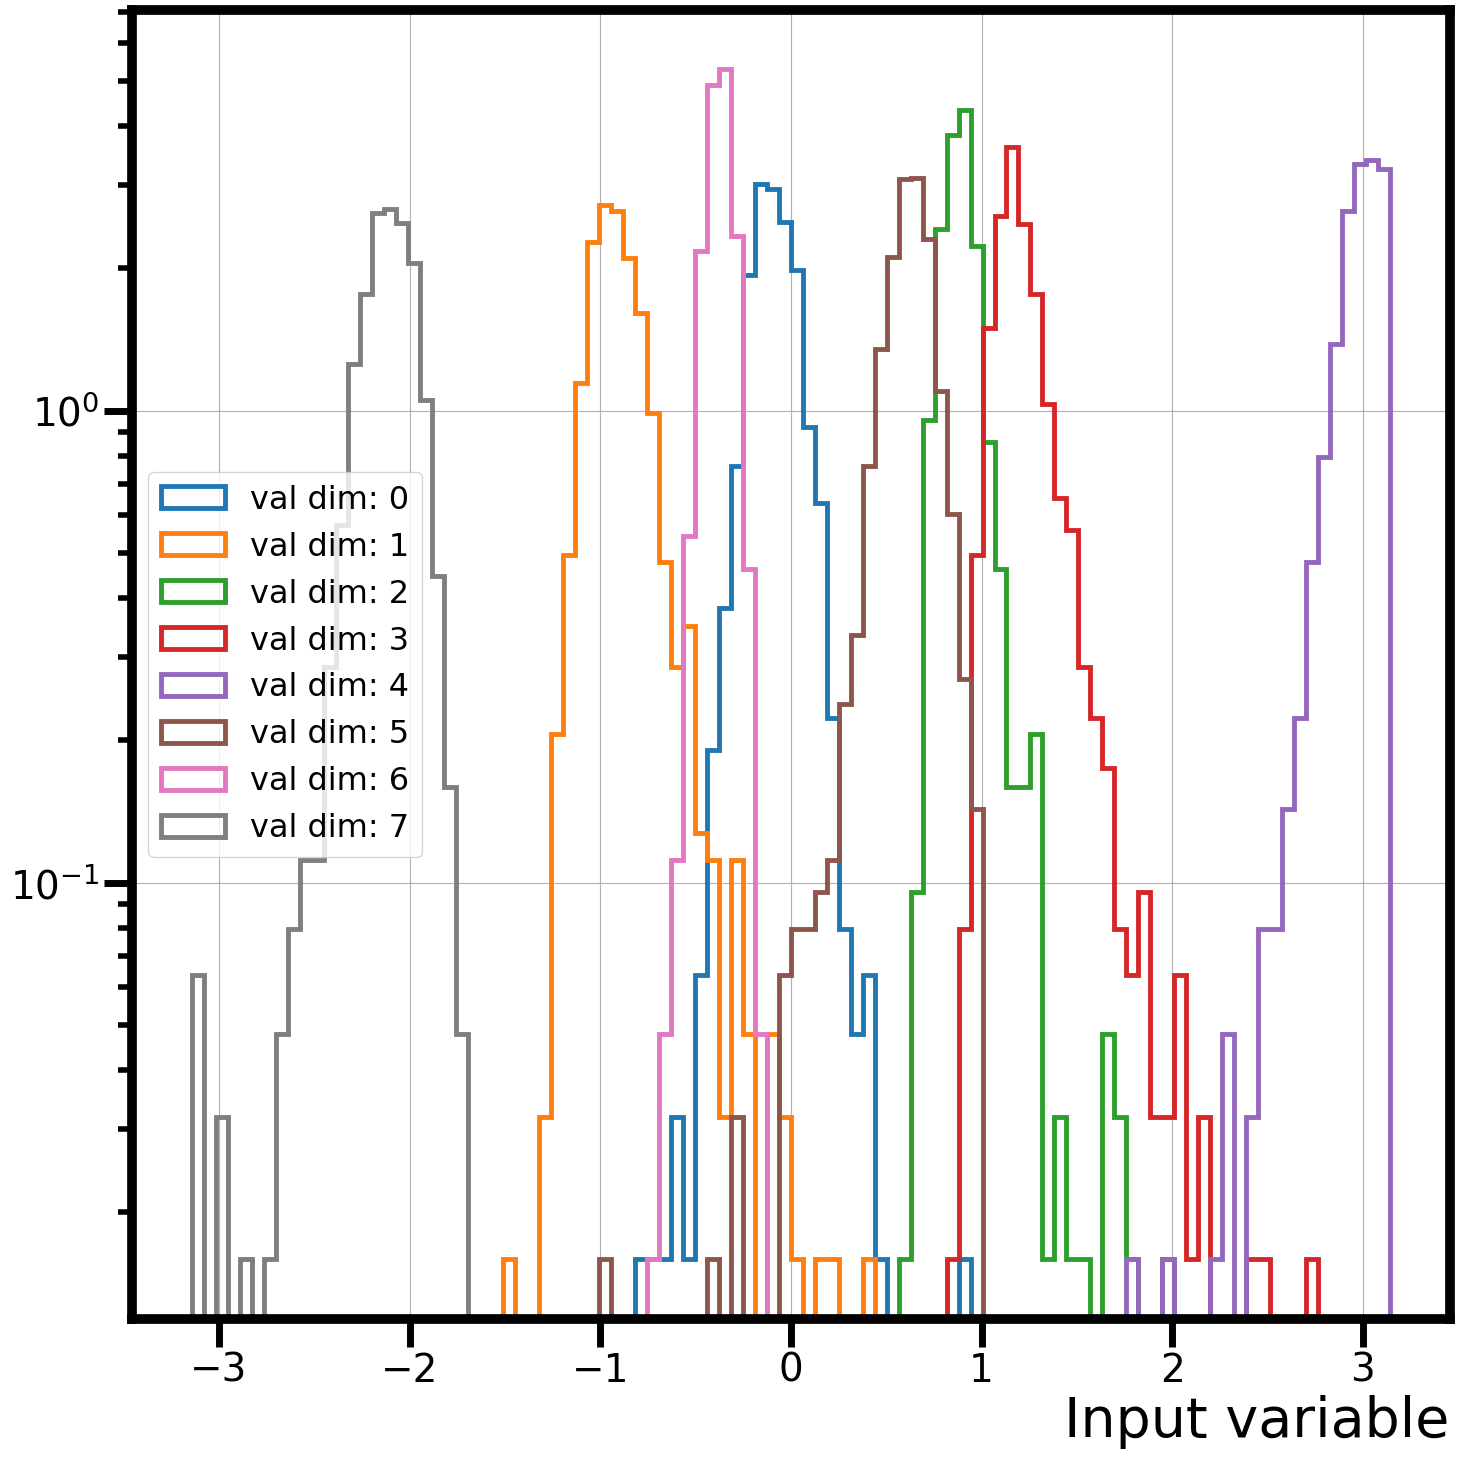

In [11]:
QAE_model = fromYaml('model/configs/EmbeddingPennyLaneQAEModel.yaml',output_path+'/models/QAE')
input_shape = background_embeddings.shape[0]
input_length = len(background_data_frame)
input_length = len(background_data_frame)
QAE_model.build_model(input_shape,embedding_min, embedding_max )
QAE_model.compile_model(input_length)
QAE_model.only_QAE_fit(background_embeddings)
QAE_model.save()
QAE_model.plot_loss()

In [10]:
QAE_model = fromFolder(output_path+'/models/QAE')

# Train the HW substrate QAE Model


In [13]:
HW_QAE_model = fromYaml('model/configs/EmbeddingHWPennyLaneQAEModel.yaml',output_path+'/models/HW_QAE')
input_shape = background_embeddings.shape[0]
input_length = len(background_data_frame)
input_length = len(background_data_frame)
HW_QAE_model.build_model(input_shape,embedding_min, embedding_max )
HW_QAE_model.compile_model(input_length)
HW_QAE_model.only_QAE_fit(background_embeddings)
HW_QAE_model.save()
HW_QAE_model.plot_loss()

Re-created existing directory: AD/transformer/all/models/HW_QAE.


TypeError: EmbeddingHWPennyLaneQAEModel.build_model() takes 2 positional arguments but 4 were given

In [11]:
HW_QAE_model = fromFolder(output_path+'/models/HW_QAE')

# Evaluate the models

In [12]:
test_labels = {"background" : 0, "ato4l" :1, "hChToTauNu" : 2, 'hToTauTau':3,'leptoquark':4, 'blackbox':5}

## Run the embedding prediction

In [ ]:
training_columns = []
dataset_list = []
for datasets in test_labels.keys():
    data_test = DataSet.fromH5(input_path+datasets+'/test/')
    data_test.normalise()

    data_test.set_label(test_labels[datasets])
    dataset_list.append(data_test)
    training_columns = data_test.training_columns
        
test_data_frame = pd.concat([dataset.data_frame for dataset in dataset_list])
test_data_frame = test_data_frame.sample(frac=1)

test_embeddings = embedding_model.encoder_predict(test_data_frame[training_columns].to_numpy(),training_columns) 

In [ ]:
os.makedirs(output_path+'/embeddings/test', exist_ok=True)
np.save(output_path+'/embeddings/test/test_embeddings.npy',test_embeddings)
test_data_frame.to_pickle(output_path+'/embeddings/test/dataset.pkl')

## Load the embeddings

In [13]:
test_embeddings = np.load(output_path+'/embeddings/test/test_embeddings.npy')
test_data_frame = pd.read_pickle(output_path+'/embeddings/test/dataset.pkl')

In [14]:
from plot.basic import error_residual, plot_histo, rates,efficiency, clusters, plot_2d

In [15]:
labels = {"background" : 0, "ato4l" :1, "hChToTauNu" : 2, "hToTauTau" : 3, "leptoquark" : 4, "blackbox": 5}


## Run the predictions with the AE models

In [16]:

output_dict = {'CAE' : {"background" : {}, "ato4l" :{}, "hChToTauNu" : {}, "hToTauTau" : {}, "leptoquark" : {}, "blackbox": {}},
               'IF'  : {"background" : {}, "ato4l" :{}, "hChToTauNu" : {}, "hToTauTau" : {}, "leptoquark" : {}, "blackbox": {}},
               'QAE' : {"background" : {}, "ato4l" :{}, "hChToTauNu" : {}, "hToTauTau" : {}, "leptoquark" : {}, "blackbox": {}},
               'HW_QAE' : {"background" : {}, "ato4l" :{}, "hChToTauNu" : {}, "hToTauTau" : {}, "leptoquark" : {}, "blackbox": {}}}

for label in labels.keys():
    print("==== Predicting for "+label+" ====")
    indices = np.where(test_data_frame["event_label"] == labels[label])
    test_index = np.random.randint(0, len(indices[0]), size=10000)
    embeddings = test_embeddings[indices[0][test_index]]
    data_frame = test_data_frame.iloc[indices[0][test_index]]

    print("Classical Autoencoder Predict")
    output_dict['CAE'][label] = {'predictions' : CAE_model.only_CAE_predict(embeddings)}
    print("Isolation Forest Predict")
    output_dict['IF'][label]  = {'predictions' : IF_model.predict_on_embedding(embeddings)}
    print("Quantum Autoencoder Predict")
    output_dict['QAE'][label] = {'predictions' : QAE_model.only_QAE_predict(embeddings)}
    print("HW Quantum Autoencoder Predict")
    output_dict['HW_QAE'][label] = {'predictions' : HW_QAE_model.only_QAE_predict(embeddings)}
    
    


==== Predicting for background ====
Classical Autoencoder Predict


2026-04-16 09:31:23.294406: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fc40c0039a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-16 09:31:23.294452: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA H100 80GB HBM3, Compute Capability 9.0
2026-04-16 09:31:23.310985: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-16 09:31:23.406393: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


 49/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

I0000 00:00:1776324684.131196 1317674 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Isolation Forest Predict
Quantum Autoencoder Predict
HW Quantum Autoencoder Predict
==== Predicting for ato4l ====
Classical Autoencoder Predict
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Isolation Forest Predict
Quantum Autoencoder Predict
HW Quantum Autoencoder Predict
==== Predicting for hChToTauNu ====
Classical Autoencoder Predict
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Isolation Forest Predict
Quantum Autoencoder Predict
HW Quantum Autoencoder Predict
==== Predicting for hToTauTau ====
Classical Autoencoder Predict
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Isolation Forest Predict
Quantum Autoencoder Predict
HW Quantum Autoencoder Predict
==== Predicting for leptoquark ====
Classical Autoencoder Predict
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Isolation Forest Predict
Quantum Autoencoder Predict
HW Quantum Autoencoder Predict
==== Predicting for blackbox ====
Classical Autoencoder Predict
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Isolation Fo

In [17]:
with open(output_path+'/models/output_dict.pkl', 'wb') as f:
    pickle.dump(output_dict, f)

## Load the predictions

In [18]:
with open(output_path+'/models/output_dict.pkl', 'rb') as f:
    output_dict = pickle.load(f)

# Plot per model output predictions labeled per event type

In [19]:
import matplotlib.pyplot as plt

plot_histo([output_dict['CAE'][dataset]['predictions'] for dataset in output_dict['CAE'].keys()], 
               [dataset for dataset in output_dict['CAE'].keys()], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)
os.makedirs(output_path+"/models/CAE/plots/testing/", exist_ok=True)
plt.savefig(f"{output_path}/models/CAE/plots/testing/outputscores.png", bbox_inches='tight')
plt.close() 

plot_histo([output_dict['IF'][dataset]['predictions'] for dataset in output_dict['IF'].keys()], 
               [dataset for dataset in output_dict['IF'].keys()], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)
os.makedirs(output_path+"/models/IF/plots/testing/", exist_ok=True)
plt.savefig(f"{output_path}/models/IF/plots/testing/outputscores.png", bbox_inches='tight')
plt.close() 

plot_histo([output_dict['QAE'][dataset]['predictions'] for dataset in output_dict['QAE'].keys()], 
               [dataset for dataset in output_dict['QAE'].keys()], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)
os.makedirs(output_path+"/models/QAE/plots/testing/", exist_ok=True)
plt.savefig(f"{output_path}/models/QAE/plots/testing/outputscores.png", bbox_inches='tight')
plt.close() 

plot_histo([output_dict['HW_QAE'][dataset]['predictions'] for dataset in output_dict['QAE'].keys()], 
               [dataset for dataset in output_dict['QAE'].keys()], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)
os.makedirs(output_path+"/models/HW_QAE/plots/testing/", exist_ok=True)
plt.savefig(f"{output_path}/models/HW_QAE/plots/testing/outputscores.png", bbox_inches='tight')
plt.close() 

<Figure size 640x480 with 0 Axes>

# Plot per process output scores labelled per model

In [20]:
os.makedirs(output_path+"/plots/testing/", exist_ok=True)
for label in labels.keys():
    plot_histo([output_dict['CAE'][label]['predictions'],output_dict['IF'][label]['predictions'],output_dict['QAE'][label]['predictions'],output_dict['HW_QAE'][label]['predictions']], 
               ['CAE','IF','QAE','HW_QAE'], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)
    plt.savefig(f"{output_path}/plots/testing/{label}_outputscores.png", bbox_inches='tight')
    plt.close() 

<Figure size 640x480 with 0 Axes>

# Plot per model ROC curves labelled per process

In [21]:
from plot.basic import ROC_curve

ROC_curve([output_dict['CAE']['background']['predictions'] for dataset in output_dict['CAE'].keys()],
          [output_dict['CAE'][dataset]['predictions'] for dataset in output_dict['CAE'].keys()],
          labels)
plt.savefig(f"{output_path}/models/CAE/plots/testing/ROC.png", bbox_inches='tight')
plt.close() 

ROC_curve([output_dict['IF']['background']['predictions'] for dataset in output_dict['IF'].keys()],
          [output_dict['IF'][dataset]['predictions'] for dataset in output_dict['IF'].keys()],
          labels)
plt.savefig(f"{output_path}/models/IF/plots/testing/ROC.png", bbox_inches='tight')
plt.close() 

ROC_curve([output_dict['QAE']['background']['predictions'] for dataset in output_dict['QAE'].keys()],
          [output_dict['QAE'][dataset]['predictions'] for dataset in output_dict['QAE'].keys()],
          labels)
plt.savefig(f"{output_path}/models/QAE/plots/testing/ROC.png", bbox_inches='tight')
plt.close() 

ROC_curve([output_dict['HW_QAE']['background']['predictions'] for dataset in output_dict['HW_QAE'].keys()],
          [output_dict['HW_QAE'][dataset]['predictions'] for dataset in output_dict['HW_QAE'].keys()],
          labels)
plt.savefig(f"{output_path}/models/HW_QAE/plots/testing/ROC.png", bbox_inches='tight')
plt.close() 



# Plot per process ROC curves labelled per model

In [22]:
for label in labels.keys():
    ROC_curve([output_dict['CAE']['background']['predictions'],output_dict['IF']['background']['predictions'],output_dict['QAE']['background']['predictions'],output_dict['HW_QAE']['background']['predictions']],
              [output_dict['CAE'][label]['predictions'],output_dict['IF'][label]['predictions'],output_dict['QAE'][label]['predictions'],output_dict['HW_QAE'][label]['predictions']],
              ['CAE','IF','QAE','HW_QAE'])
    
    plt.savefig(f"{output_path}/plots/testing/{label}_ROC.png", bbox_inches='tight')
    plt.close() 


# Augmentations

In [ ]:
from plot.plot_latent import plot_latent, plot_PCA
from sklearn.decomposition import PCA

In [ ]:
training_columns = []
dataset_list = []

for datasets in labels.keys():
    print(datasets)
    data_test = DataSet.fromH5(input_path+datasets+'/test/')
    data_test_dataframe = data_test.data_frame.sample(n=10000)
    
    #augment_test.drop_a_soft_one('jet')
    data_test.eta_smear()
    data_test.pt_smear()
    data_test.phi_smear()
    #data_test.phi_rotate()
    
    data_test.normalise()

    data_test.set_label(test_labels[datasets])
    dataset_list.append(data_test)
    training_columns = data_test.training_columns
        
augment_data_frame = pd.concat([dataset.data_frame for dataset in dataset_list])
augment_data_frame = augment_data_frame.sample(frac=1)

augment_embeddings = embedding_model.encoder_predict(augment_data_frame[training_columns].to_numpy(),training_columns) 

In [ ]:
os.makedirs(output_path+'/embeddings/augment', exist_ok=True)
np.save(output_path+'/embeddings/augment/augment_embeddings.npy',augment_embeddings)
augment_data_frame.to_pickle(output_path+'/embeddings/augment/dataset.pkl')

In [ ]:
augment_embeddings = np.load(output_path+'/embeddings/augment/augment_embeddings.npy')
augment_data_frame = pd.read_pickle(output_path+'/embeddings/augment/dataset.pkl')

# Compare Latent Spaces for background Sample

In [ ]:
background_indices = np.where(test_data_frame["event_label"] == 0)
test_index = np.random.randint(0, len(background_indices[0]), size=10000)
background_test_embeddings = test_embeddings[background_indices[test_index]]
background_test_data_frame = test_data_frame.iloc[background_indices[test_index]]

background_indices = np.where(augment_data_frame["event_label"] == 0)
background_augment_embeddings = augment_embeddings[background_indices]
background_augment_data_frame = augment_data_frame.iloc[background_indices]
    
latent_vector = np.concatenate([background_test_embeddings,background_augment_embeddings], axis=0)
event_label_vector = np.concatenate([np.zeros(len(background_test_embeddings)),np.ones(len(background_augment_embeddings))], axis=0)

os.makedirs(f"{output_path}/embeddings/plots/background", exist_ok=True)

plot_latent(latent_vector, event_label_vector, {'test':'test','augment':'augment'}, f"{output_path}/embeddings/plots/background")
    
pca = PCA(n_components=2)
event_principle_components = pca.fit_transform(latent_vector)

event_xmax, event_xmin = np.percentile(event_principle_components[:,0],99), np.percentile(event_principle_components[:,0],1)
event_ymax, event_ymin = np.percentile(event_principle_components[:,1],99), np.percentile(event_principle_components[:,1],1)
    
plot_PCA(event_principle_components, event_label_vector,((event_xmin, event_xmax),(event_ymin, event_ymax)), {'test':'test','augment':'augment'}, f"{output_path}/embeddings/plots/background")




